In [ ]:
pip install pandas numpy pywavelets matplotlib
!pip install --user scikit-learn
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/29/d4/1244ab8edf173a10fd601f7e13b9566c1b525c4f365d6bee918e68381889/pandas-2.2.3-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/42/6e/55580a538116d16ae7c9aa17d4edd56e83f42126cb1dfe7a684da7925d2c/numpy-2.2.3-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------------- ------------------ 30.7/60.8 kB 325.1 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/60.8 kB 326.8 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 404.8 kB/s eta 0:00:00
  Obtaining dependency information for pywavelets from https://files.pythonhosted.org/packages/1c/88/9e2aa9d5fde08bfc0fb18ffb1b


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import pandas as pd
import numpy as np
import pywt
import matplotlib.pyplot as plt
import math

In [10]:
from sklearn.preprocessing import StandardScaler

In [21]:
e1 = pd.read_excel(r"c:\Users\ma.benavidess1\Downloads\EICH101.xlsx")

# Filtrar registros según ORIG_RAW_VOLUME
e1 = e1[e1["ORIG_RAW_VOLUME"] <= 60]

# Convertir EFFECTIVE_DATE a formato de fecha
e1["EFFECTIVE_DATE"] = pd.to_datetime(e1["EFFECTIVE_DATE"], errors='coerce')

# Aplicar normalización Z-score
scaler = StandardScaler()
columns_to_normalize = ["STD_VOLUME", "ORIG_STD_VOLUME", "ORIG_TEMPERATURE","TEMPERATURE","PRESSURE","ORIG_PRESSURE","RAW_VOLUME","ORIG_RAW_VOLUME"]  # Ajusta si necesitas más
e1[columns_to_normalize] = scaler.fit_transform(e1[columns_to_normalize])

# Guardar el resultado en un CSV en la misma carpeta donde está el pipeline
output_path = "datos_procesados_empresa1.csv"
e1.to_csv(output_path, index=False)

print(f"Archivo guardado en {output_path}")

Archivo guardado en datos_procesados_empresa1.csv


In [23]:
# Calcular el percentil 99 global para evitar que las anomalías dominen
global_max = np.percentile(e1["ORIG_RAW_VOLUME"], 99)
 
# Aplicar normalización dividiendo por ese valor máximo
e1["ORIG_RAW_VOLUME_NORM"] = e1["ORIG_RAW_VOLUME"] / global_max
e1["ORIG_RAW_VOLUME_NORM"] = np.clip(e1["ORIG_RAW_VOLUME_NORM"], 0, 1)

In [24]:
# Crear la carpeta donde se guardarán las imágenes
output_folder = r"c:\Users\ma.benavidess1\Downloads\ProyectoGradoGEB\imagenes_diarias"
os.makedirs(output_folder, exist_ok=True)


In [26]:
# Escalas para la Transformada Wavelet Continua (CWT)
scales = np.arange(1, 128)

# Recorrer el archivo secuencialmente
e1_sorted = e1.sort_values(by="EFFECTIVE_DATE")
 
# Obtener los años únicos en el DataFrame
years = e1_sorted['EFFECTIVE_DATE'].dt.year.unique()
 
for year in years:
    e1_year = e1_sorted[e1_sorted['EFFECTIVE_DATE'].dt.year == year]
    
    # Obtener los días únicos ordenados
    days = sorted(e1_year['EFFECTIVE_DATE'].dt.date.unique())
 
    for day in days:
        e1_day = e1_year[e1_year['EFFECTIVE_DATE'].dt.date == day]
        if not e1_day.empty:
            # Extraer la señal del día (manteniendo valores originales sin escalar)
            signal_day = e1_day['ORIG_RAW_VOLUME'].values
 
            # Aplicar la Transformada Wavelet Continua (CWT) con Morlet
            coefficients, frequencies = pywt.cwt(signal_day, scales, 'morl')
 
            # Crear la figura del escalograma
            plt.figure(figsize=(10, 6))
            plt.imshow(np.abs(coefficients), aspect="auto", cmap="jet",
                       extent=[0, len(signal_day), scales[-1], scales[0]])

            plt.colorbar(label="Magnitud")
            plt.title(f"Escalograma - Año {year} - Día {day}", fontsize=12, fontweight="bold")
            plt.xlabel("Horas del Día")
            plt.ylabel("Escala")
 
            # Guardar la imagen
            filename = f"Año{year}_Día{day}.png".replace(" ", "")
            filepath = os.path.join(output_folder, filename)
            plt.savefig(filepath, dpi=300, bbox_inches="tight")
            plt.close()
 
# Listar los archivos generados
generated_files = os.listdir(output_folder)

print("Ejemplo de archivos generados:", generated_files[:10])  # Mostrar solo los primeros 10 archivos como muestra

Ejemplo de archivos generados: ['Año2018_Día2018-09-03.png', 'Año2018_Día2018-09-04.png', 'Año2018_Día2018-09-05.png', 'Año2018_Día2018-09-06.png', 'Año2018_Día2018-09-07.png', 'Año2018_Día2018-09-08.png', 'Año2018_Día2018-09-09.png', 'Año2018_Día2018-09-10.png', 'Año2018_Día2018-09-11.png', 'Año2018_Día2018-09-12.png']


Found 1370 images belonging to 2 classes.
Found 1311 images belonging to 2 classes.
Found 645 images belonging to 2 classes.
Total imágenes en entrenamiento: 1370
Total imágenes en validación: 1311
Total imágenes en prueba: 645

Entrenando modelo: MobileNetV2


c:\Users\diana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 964s 22s/step - accuracy: 0.6875 - loss: 0.5719 - val_accuracy: 0.7971 - val_loss: 0.4305
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 613s 14s/step - accuracy: 0.7942 - loss: 0.4282 - val_accuracy: 0.7735 - val_loss: 0.4480
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.7989 - loss: 0.4293 - val_accuracy: 0.8330 - val_loss: 0.3729
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.8225 - loss: 0.3909 - val_accuracy: 0.8505 - val_loss: 0.3537
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.8333 - loss: 0.3655 - val_accuracy: 0.8513 - val_loss: 0.3437
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.8429 - loss: 0.3462 - val_accuracy: 0.8596 - val_loss: 0.3322
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.8540 - loss: 0.3408 - val_accuracy: 0.8520 - val_loss: 0.3336
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 887s 21s/step - accuracy: 0.8379 - loss: 0.3556 - val_accuracy: 0.8589 

Precisión de MobileNetV2 en el conjunto de prueba: 71.16%

Guardando datos de validación y prueba para MobileNetV2...

✅ Datos guardados en X_val_MobileNetV2.npy, y_val_MobileNetV2.npy, X_test_MobileNetV2.npy y y_test_MobileNetV2.npy

Evaluando métricas para MobileNetV2...

41/41 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step
Matriz de Confusión:
 [[552  98]
 [ 89 572]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86       650
           1       0.85      0.87      0.86       661

    accuracy                           0.86      1311
   macro avg       0.86      0.86      0.86      1311
weighted avg       0.86      0.86      0.86      1311

F1-Score: 0.8573458513429544
Precisión: 0.8574117528040033
Error Tipo I (Falsos Positivos): 98
Error Tipo II (Falsos Negativos): 89


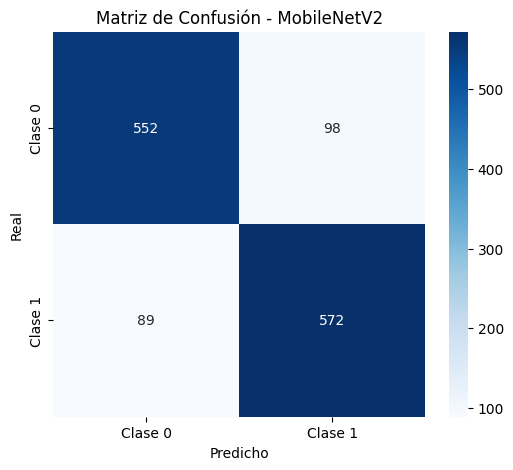


Entrenando modelo: ResNet34
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.5364 - loss: 0.7077 - val_accuracy: 0.6590 - val_loss: 0.6451
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 170s 4s/step - accuracy: 0.6090 - loss: 0.6516 - val_accuracy: 0.7132 - val_loss: 0.6117
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 596s 14s/step - accuracy: 0.6619 - loss: 0.6114 - val_accuracy: 0.6987 - val_loss: 0.5956
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.6618 - loss: 0.6035 - val_accuracy: 0.7368 - val_loss: 0.5519
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 371s 9s/step - accuracy: 0.7445 - loss: 0.5430 - val_accuracy: 0.6255 - val_loss: 0.6107
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 159s 4s/step - accuracy: 0.6769 - loss: 0.5794 - val_accuracy: 0.7079 - val_loss: 0.5531
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1748s 42s/step - accuracy: 0.7274 - loss: 0.5253 - val_accuracy: 0.7346 - val_loss: 0.5180
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.7586 - loss: 0

Precisión de ResNet34 en el conjunto de prueba: 64.34%

Guardando datos de validación y prueba para ResNet34...

✅ Datos guardados en X_val_ResNet34.npy, y_val_ResNet34.npy, X_test_ResNet34.npy y y_test_ResNet34.npy

Evaluando métricas para ResNet34...

41/41 ━━━━━━━━━━━━━━━━━━━━ 624s 14s/step
Matriz de Confusión:
 [[531 119]
 [167 494]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       650
           1       0.81      0.75      0.78       661

    accuracy                           0.78      1311
   macro avg       0.78      0.78      0.78      1311
weighted avg       0.78      0.78      0.78      1311

F1-Score: 0.7816203150484539
Precisión: 0.7834981945236221
Error Tipo I (Falsos Positivos): 119
Error Tipo II (Falsos Negativos): 167


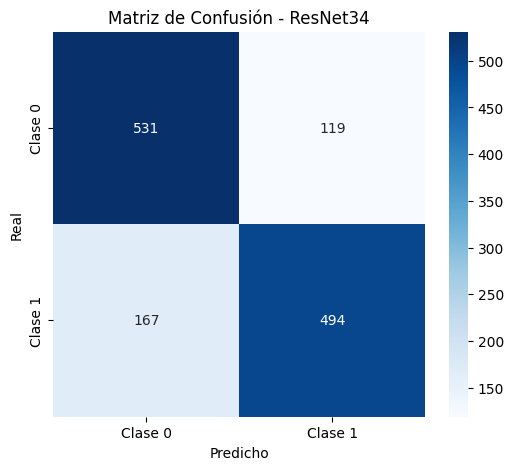


Entrenando modelo: VGG16bn
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2966s 69s/step - accuracy: 0.5510 - loss: 1.4521 - val_accuracy: 0.7551 - val_loss: 0.6184
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2250s 53s/step - accuracy: 0.7614 - loss: 0.5850 - val_accuracy: 0.8085 - val_loss: 0.5415
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1388s 32s/step - accuracy: 0.8062 - loss: 0.5403 - val_accuracy: 0.8032 - val_loss: 0.5248
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 332s 8s/step - accuracy: 0.8223 - loss: 0.5232 - val_accuracy: 0.8474 - val_loss: 0.5060
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 370s 9s/step - accuracy: 0.8446 - loss: 0.5221 - val_accuracy: 0.8261 - val_loss: 0.4914
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 400s 9s/step - accuracy: 0.8392 - loss: 0.4981 - val_accuracy: 0.8696 - val_loss: 0.4867
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 361s 8s/step - accuracy: 0.8493 - loss: 0.4840 - val_accuracy: 0.8421 - val_loss: 0.4682
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 343s 8s/step - accuracy: 0.8466 - loss:

Precisión de VGG16bn en el conjunto de prueba: 77.21%

Guardando datos de validación y prueba para VGG16bn...

✅ Datos guardados en X_val_VGG16bn.npy, y_val_VGG16bn.npy, X_test_VGG16bn.npy y y_test_VGG16bn.npy

Evaluando métricas para VGG16bn...

41/41 ━━━━━━━━━━━━━━━━━━━━ 173s 4s/step
Matriz de Confusión:
 [[494 156]
 [ 29 632]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.94      0.76      0.84       650
           1       0.80      0.96      0.87       661

    accuracy                           0.86      1311
   macro avg       0.87      0.86      0.86      1311
weighted avg       0.87      0.86      0.86      1311

F1-Score: 0.8574312710746311
Precisión: 0.8726926521511329
Error Tipo I (Falsos Positivos): 156
Error Tipo II (Falsos Negativos): 29


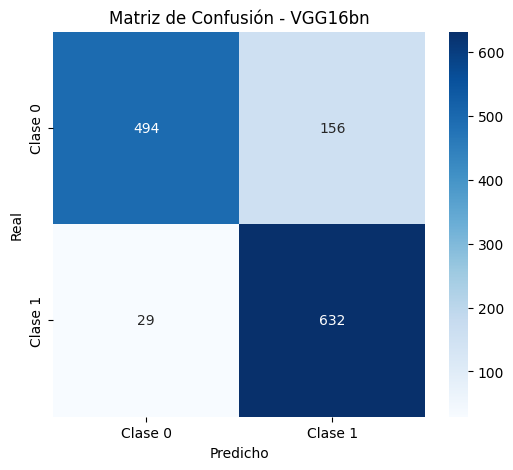

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt

# Parámetros
img_size = (224, 224)  
batch_size = 32
epochs = 10
data_dir = r"C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/imagenes_diarias"  # 📌 Reemplaza con la ruta real

# Generador de datos con división en entrenamiento (70%), validación (20%) y prueba (10%)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)  # 20% para validación y prueba

test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.33)  # Divide el 20% en 10% validación y 10% prueba

# Generador de entrenamiento (70% de los datos)
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

# Generador de validación (20% de los datos)
val_generator = test_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",  # La primera mitad del 20% restante
    shuffle=False
)

# Generador de prueba (10% de los datos)
test_generator = test_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",  # La otra mitad del 20% restante
    shuffle=False
)

print(f"Total imágenes en entrenamiento: {train_generator.samples}")
print(f"Total imágenes en validación: {val_generator.samples}")
print(f"Total imágenes en prueba: {test_generator.samples}")

# Función para construir modelos
def build_model(base_model):
    base_model.trainable = False  
    
    inputs = base_model.input
    x = base_model.output
    x = GlobalAveragePooling2D()(x) if "mobilenet" in base_model.name.lower() or "resnet" in base_model.name.lower() else Flatten()(x)
    
    x = Dense(128, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)  
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Definir los modelos
models = {
    "MobileNetV2": MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),
    "ResNet34": ResNet50(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),  
    "VGG16bn": VGG16(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
}

# Entrenar y evaluar cada modelo
for name, base_model in models.items():
    print(f"\nEntrenando modelo: {name}")
    
    model = build_model(base_model)  

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs
    )

    # Evaluar en conjunto de prueba (final)
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"Precisión de {name} en el conjunto de prueba: {test_acc * 100:.2f}%")

    # Guardar el modelo
    model.save(f"modelo_anomalias_{name}.h5")  

    # 🚀 Guardar datos de validación y prueba en NumPy
    print(f"\nGuardando datos de validación y prueba para {name}...\n")
    
    X_val = np.concatenate([val_generator[i][0] for i in range(len(val_generator))])
    y_val = np.concatenate([val_generator[i][1] for i in range(len(val_generator))])

    X_test = np.concatenate([test_generator[i][0] for i in range(len(test_generator))])
    y_test = np.concatenate([test_generator[i][1] for i in range(len(test_generator))])

    np.save(f"X_val_{name}.npy", X_val)
    np.save(f"y_val_{name}.npy", y_val)
    np.save(f"X_test_{name}.npy", X_test)
    np.save(f"y_test_{name}.npy", y_test)

    print(f"✅ Datos guardados en X_val_{name}.npy, y_val_{name}.npy, X_test_{name}.npy y y_test_{name}.npy")

    # 🚀 Evaluar métricas con conjunto de prueba
    print(f"\nEvaluando métricas para {name}...\n")

    # Obtener etiquetas reales de validación
    y_val_classes = val_generator.classes  

    # Obtener predicciones del modelo
    y_pred_proba = model.predict(val_generator)  
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()  

    # Matriz de Confusión
    matriz_conf = confusion_matrix(y_val_classes, y_pred)
    print("Matriz de Confusión:\n", matriz_conf)

    # Reporte de clasificación
    print("Reporte de Clasificación:\n", classification_report(y_val_classes, y_pred))

    # Obtener métricas individuales
    f1 = f1_score(y_val_classes, y_pred, average='weighted')
    precision = precision_score(y_val_classes, y_pred, average='weighted')

    print(f"F1-Score: {f1}")
    print(f"Precisión: {precision}")

    # Extraer valores de la matriz de confusión
    TN, FP, FN, TP = matriz_conf.ravel()

    # Error Tipo I (Falsos Positivos)
    error_tipo_1 = FP

    # Error Tipo II (Falsos Negativos)
    error_tipo_2 = FN

    print(f"Error Tipo I (Falsos Positivos): {error_tipo_1}")
    print(f"Error Tipo II (Falsos Negativos): {error_tipo_2}")

    # 📊 Visualizar la Matriz de Confusión
    plt.figure(figsize=(6, 5))
    sns.heatmap(matriz_conf, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión - {name}")
    plt.show()
